In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import tifffile as tiff

In [3]:
import sklearn
import tifffile
import tensorflow as tf

print("All libraries are working")
print(tf.__version__)

All libraries are working
2.21.0


In [51]:
import os 

ds = "Kaggle_Prepared"

sets = ["train", "val"]

mods = ["HS", "MS", "RGB"]

for s in sets:
    print("\nSet:", s)

    for m in mods:
        p = os.path.join(ds, s, m) 

        if os.path.exists(p):
            fs = os.listdir(p)  
            print(m, ":", len(fs), "files")
        else:
            print(m, ": folder not found")


Set: train
HS : 600 files
MS : 600 files
RGB : 600 files

Set: val
HS : 300 files
MS : 300 files
RGB : 300 files


In [52]:
import os 

ds = "Kaggle_Prepared"  

sets = ["train", "val"]  
mods = ["HS", "MS", "RGB"]  


for s in sets:
    print("\nSet:", s)

    
    for m in mods:
        p = os.path.join(ds, s, m)  

        exts = [] 

        
        for f in os.listdir(p):
            ex = os.path.splitext(f)[1] 
            exts.append(ex)

        exts = set(exts)  

        print(m, "extensions:", exts)


Set: train
HS extensions: {'.tif'}
MS extensions: {'.tif'}
RGB extensions: {'.png'}

Set: val
HS extensions: {'.tif'}
MS extensions: {'.tif'}
RGB extensions: {'.png'}


In [53]:
import os

ds = "Kaggle_Prepared"  

sets = ["train", "val"]  
mods = ["HS", "MS", "RGB"]  


for s in sets:
    print("\nSet:", s)

    names = {}  

    
    for m in mods:
        p = os.path.join(ds, s, m)  

        
        fs = [
            os.path.splitext(f)[0]
            for f in os.listdir(p)
        ]

        names[m] = set(fs)  

        print(m, "samples:", len(names[m]))

    
    common = names["HS"] & names["MS"] & names["RGB"]

    print("Common samples:", len(common))

    
    for m in mods:
        miss = common - names[m]
        print("Missing in", m, ":", len(miss))

   
    for m in mods:
        extra = names[m] - common
        print("Extra in", m, ":", len(extra))

        
        if len(extra) > 0:
            print("Examples:", list(extra)[:5])


Set: train
HS samples: 600
MS samples: 600
RGB samples: 600
Common samples: 600
Missing in HS : 0
Missing in MS : 0
Missing in RGB : 0
Extra in HS : 0
Extra in MS : 0
Extra in RGB : 0

Set: val
HS samples: 300
MS samples: 300
RGB samples: 300
Common samples: 300
Missing in HS : 0
Missing in MS : 0
Missing in RGB : 0
Extra in HS : 0
Extra in MS : 0
Extra in RGB : 0


In [7]:
import os  

ds = "Kaggle_Prepared"  

sets = ["train", "val"]  
mods = ["HS", "MS", "RGB"]  


for s in sets:
    print("\nSet:", s)

    for m in mods:
        p = os.path.join(ds, s, m)  

        fs = os.listdir(p)  
        fs = sorted(fs)    

        print("\nModality:", m)
        print("First 10 files:")

        for f in fs[:10]:
            print(f)


Set: train

Modality: HS
First 10 files:
Health_hyper_1.tif
Health_hyper_10.tif
Health_hyper_100.tif
Health_hyper_101.tif
Health_hyper_102.tif
Health_hyper_103.tif
Health_hyper_104.tif
Health_hyper_105.tif
Health_hyper_106.tif
Health_hyper_107.tif

Modality: MS
First 10 files:
Health_hyper_1.tif
Health_hyper_10.tif
Health_hyper_100.tif
Health_hyper_101.tif
Health_hyper_102.tif
Health_hyper_103.tif
Health_hyper_104.tif
Health_hyper_105.tif
Health_hyper_106.tif
Health_hyper_107.tif

Modality: RGB
First 10 files:
Health_hyper_1.png
Health_hyper_10.png
Health_hyper_100.png
Health_hyper_101.png
Health_hyper_102.png
Health_hyper_103.png
Health_hyper_104.png
Health_hyper_105.png
Health_hyper_106.png
Health_hyper_107.png

Set: val

Modality: HS
First 10 files:
val_000a83c1.tif
val_00a704b1.tif
val_01dde030.tif
val_024df365.tif
val_02afcb0e.tif
val_03864ba6.tif
val_0537e324.tif
val_059983e0.tif
val_05cee914.tif
val_07af871a.tif

Modality: MS
First 10 files:
val_000a83c1.tif
val_00a704b1.tif
va

In [8]:

ds = "Kaggle_Prepared"  
p = os.path.join(ds, "train", "RGB")  

labels = []  


for f in os.listdir(p):
    name = os.path.splitext(f)[0]  

    
    lab = name.split("_hyper")[0]

    labels.append(lab)


cls = sorted(set(labels))

print("Number of classes:", len(cls))
print("Classes:", cls)


for c in cls:
    print(c, ":", labels.count(c))

Number of classes: 3
Classes: ['Health', 'Other', 'Rust']
Health : 200
Other : 200
Rust : 200


In [9]:
import os  

ds = "Kaggle_Prepared"


for f in os.listdir(ds):
    print(f)

train
val


In [10]:
import os  
import pandas as pd  

ds = "Kaggle_Prepared"  


hs = os.path.join(ds, "train", "HS")
ms = os.path.join(ds, "train", "MS")
rgb = os.path.join(ds, "train", "RGB")

rows = []  


for f in os.listdir(rgb):
    name = os.path.splitext(f)[0] 


    lab = name.split("_hyper")[0]


    hs_p = os.path.join(hs, name + ".tif")
    ms_p = os.path.join(ms, name + ".tif")
    rgb_p = os.path.join(rgb, name + ".png")

  
    if os.path.exists(hs_p) and os.path.exists(ms_p) and os.path.exists(rgb_p):
        rows.append([name, lab, hs_p, ms_p, rgb_p])


df = pd.DataFrame(rows, columns=["name", "label", "hs", "ms", "rgb"])

print(df.head())
print("\nTotal samples:", len(df))
print("\nClass distribution:")
print(df["label"].value_counts())

               name   label                                             hs  \
0    Health_hyper_1  Health    Kaggle_Prepared\train\HS\Health_hyper_1.tif   
1   Health_hyper_10  Health   Kaggle_Prepared\train\HS\Health_hyper_10.tif   
2  Health_hyper_100  Health  Kaggle_Prepared\train\HS\Health_hyper_100.tif   
3  Health_hyper_101  Health  Kaggle_Prepared\train\HS\Health_hyper_101.tif   
4  Health_hyper_102  Health  Kaggle_Prepared\train\HS\Health_hyper_102.tif   

                                              ms  \
0    Kaggle_Prepared\train\MS\Health_hyper_1.tif   
1   Kaggle_Prepared\train\MS\Health_hyper_10.tif   
2  Kaggle_Prepared\train\MS\Health_hyper_100.tif   
3  Kaggle_Prepared\train\MS\Health_hyper_101.tif   
4  Kaggle_Prepared\train\MS\Health_hyper_102.tif   

                                              rgb  
0    Kaggle_Prepared\train\RGB\Health_hyper_1.png  
1   Kaggle_Prepared\train\RGB\Health_hyper_10.png  
2  Kaggle_Prepared\train\RGB\Health_hyper_100.png  
3  Kaggle_

In [11]:
from sklearn.model_selection import train_test_split  


tr_df, va_df = train_test_split(
    df,
    test_size=0.2,         
    stratify=df["label"],   
    random_state=42         
)

print("Train samples:", len(tr_df))
print("Validation samples:", len(va_df))

print("\nTrain distribution:")
print(tr_df["label"].value_counts())

print("\nValidation distribution:")
print(va_df["label"].value_counts())

Train samples: 480
Validation samples: 120

Train distribution:
label
Rust      160
Health    160
Other     160
Name: count, dtype: int64

Validation distribution:
label
Health    40
Other     40
Rust      40
Name: count, dtype: int64


In [12]:
tr_df.to_csv("train_split.csv", index=False)
va_df.to_csv("val_split.csv", index=False)

print("Splits saved successfully")

Splits saved successfully


In [13]:
import numpy as np
from PIL import Image

In [14]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import tifffile as tiff

sz = 224  

In [15]:
cls = sorted(df["label"].unique())

mp = {c: i for i, c in enumerate(cls)}

print("Classes:", cls)
print("Label map:", mp)

Classes: ['Health', 'Other', 'Rust']
Label map: {'Health': 0, 'Other': 1, 'Rust': 2}


In [16]:
def load_rgb(d):
    xs = []  
    ys = [] 

    for i, r in d.iterrows():
        p = r["rgb"]     
        lab = r["label"]  

        img = Image.open(p).convert("RGB")  
        img = img.resize((sz, sz))          

        arr = np.array(img) / 255.0        

        xs.append(arr)
        ys.append(mp[lab])

        if len(xs) % 50 == 0:
            print("Loaded:", len(xs), "images")

    xs = np.array(xs, dtype="float32")
    ys = np.array(ys, dtype="int32")

    return xs, ys


xtr_rgb, ytr = load_rgb(tr_df)
xva_rgb, yva = load_rgb(va_df)

print("Train RGB shape:", xtr_rgb.shape)
print("Train labels shape:", ytr.shape)

print("Validation RGB shape:", xva_rgb.shape)
print("Validation labels shape:", yva.shape)

Loaded: 50 images
Loaded: 100 images
Loaded: 150 images
Loaded: 200 images
Loaded: 250 images
Loaded: 300 images
Loaded: 350 images
Loaded: 400 images
Loaded: 450 images
Loaded: 50 images
Loaded: 100 images
Train RGB shape: (480, 224, 224, 3)
Train labels shape: (480,)
Validation RGB shape: (120, 224, 224, 3)
Validation labels shape: (120,)


In [17]:
import tifffile as tiff  
import numpy as np      

p = tr_df.iloc[0]["ms"]

img = tiff.imread(p)

print("MS image shape:", img.shape)
print("MS min:", img.min())
print("MS max:", img.max())

MS image shape: (64, 64, 5)
MS min: 161
MS max: 5112


In [18]:
import tifffile as tiff  
import numpy as np       

def load_ms(d):
    xs = []  
    ys = []  

    for i, r in d.iterrows():
        p = r["ms"]      
        lab = r["label"]  

        img = tiff.imread(p)  

        arr = np.array(img, dtype="float32")  

        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)

        xs.append(arr)      
        ys.append(mp[lab])  

        
        if len(xs) % 50 == 0:
            print("Loaded:", len(xs), "MS images")

    xs = np.array(xs, dtype="float32")  
    ys = np.array(ys, dtype="int32")    

    return xs, ys


xtr_ms, ytr_ms = load_ms(tr_df)

xva_ms, yva_ms = load_ms(va_df)

print("Train MS shape:", xtr_ms.shape)
print("Train labels shape:", ytr_ms.shape)

print("Validation MS shape:", xva_ms.shape)
print("Validation labels shape:", yva_ms.shape)

Loaded: 50 MS images
Loaded: 100 MS images
Loaded: 150 MS images
Loaded: 200 MS images
Loaded: 250 MS images
Loaded: 300 MS images
Loaded: 350 MS images
Loaded: 400 MS images
Loaded: 450 MS images
Loaded: 50 MS images
Loaded: 100 MS images
Train MS shape: (480, 64, 64, 5)
Train labels shape: (480,)
Validation MS shape: (120, 64, 64, 5)
Validation labels shape: (120,)


In [19]:
p = tr_df.iloc[0]["hs"]

img = tiff.imread(p)

print("HS image shape:", img.shape)
print("HS min:", img.min())
print("HS max:", img.max())

HS image shape: (32, 32, 125)
HS min: 0
HS max: 4827


In [20]:
import tifffile as tiff
from collections import Counter


def check_hs(d):
    shapes = []
    bad = []

    for i, r in d.iterrows():
        p = r["hs"]
        img = tiff.imread(p)

        shapes.append(img.shape)

        
        if img.shape != (32, 32, 125):
            bad.append((p, img.shape))

    print("Unique shapes:")
    print(Counter(shapes))

    print("\nDifferent shapes:")
    for b in bad[:20]:
        print(b)

check_hs(tr_df)

Unique shapes:
Counter({(32, 32, 125): 394, (32, 32, 126): 86})

Different shapes:
('Kaggle_Prepared\\train\\HS\\Other_hyper_23.tif', (32, 32, 126))
('Kaggle_Prepared\\train\\HS\\Other_hyper_196.tif', (32, 32, 126))
('Kaggle_Prepared\\train\\HS\\Health_hyper_141.tif', (32, 32, 126))
('Kaggle_Prepared\\train\\HS\\Other_hyper_7.tif', (32, 32, 126))
('Kaggle_Prepared\\train\\HS\\Rust_hyper_147.tif', (32, 32, 126))
('Kaggle_Prepared\\train\\HS\\Rust_hyper_143.tif', (32, 32, 126))
('Kaggle_Prepared\\train\\HS\\Health_hyper_145.tif', (32, 32, 126))
('Kaggle_Prepared\\train\\HS\\Rust_hyper_36.tif', (32, 32, 126))
('Kaggle_Prepared\\train\\HS\\Health_hyper_128.tif', (32, 32, 126))
('Kaggle_Prepared\\train\\HS\\Other_hyper_195.tif', (32, 32, 126))
('Kaggle_Prepared\\train\\HS\\Other_hyper_61.tif', (32, 32, 126))
('Kaggle_Prepared\\train\\HS\\Health_hyper_94.tif', (32, 32, 126))
('Kaggle_Prepared\\train\\HS\\Health_hyper_136.tif', (32, 32, 126))
('Kaggle_Prepared\\train\\HS\\Health_hyper_147.tif

In [21]:
h = 32
w = 32
b = 125

def fix_hs(arr):
    arr = np.array(arr, dtype="float32")

    
    out = np.zeros((h, w, b), dtype="float32")

    
    hh = min(arr.shape[0], h)
    ww = min(arr.shape[1], w)
    bb = min(arr.shape[2], b)

    
    out[:hh, :ww, :bb] = arr[:hh, :ww, :bb]

    return out

def load_hs(d):
    xs = []
    ys = []

    for i, r in d.iterrows():
        p = r["hs"]
        lab = r["label"]

        img = tiff.imread(p)

        arr = fix_hs(img)

        
        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)

        xs.append(arr)
        ys.append(mp[lab])

        if len(xs) % 50 == 0:
            print("Loaded:", len(xs), "HS images")

    xs = np.array(xs, dtype="float32")
    ys = np.array(ys, dtype="int32")

    return xs, ys

xtr_hs, ytr_hs = load_hs(tr_df)

xva_hs, yva_hs = load_hs(va_df)

print("Train HS shape:", xtr_hs.shape)
print("Train labels shape:", ytr_hs.shape)

print("Validation HS shape:", xva_hs.shape)
print("Validation labels shape:", yva_hs.shape)

Loaded: 50 HS images
Loaded: 100 HS images
Loaded: 150 HS images
Loaded: 200 HS images
Loaded: 250 HS images
Loaded: 300 HS images
Loaded: 350 HS images
Loaded: 400 HS images
Loaded: 450 HS images
Loaded: 50 HS images
Loaded: 100 HS images
Train HS shape: (480, 32, 32, 125)
Train labels shape: (480,)
Validation HS shape: (120, 32, 32, 125)
Validation labels shape: (120,)


In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization

nc = len(cls)

m1 = Sequential()

m1.add(Input(shape=(224, 224, 3)))

m1.add(Conv2D(32, (3, 3), activation="relu", padding="same"))
m1.add(MaxPooling2D((2, 2)))

m1.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
m1.add(MaxPooling2D((2, 2)))

m1.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
m1.add(MaxPooling2D((2, 2)))

m1.add(BatchNormalization())

m1.add(GlobalAveragePooling2D())

m1.add(Dense(128, activation="relu"))

m1.add(Dropout(0.3))

m1.add(Dense(nc, activation="softmax"))

m1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 28, 28, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 110,659 (432.26 KB)

 Trainable params: 110,403 (431.26 KB)

 Non-trainable params: 256 (1.00 KB)

In [23]:
m1.compile(
    optimizer="adam",                    
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"]                 

print("Model compiled successfully")

Model compiled successfully


In [24]:
es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",       
    patience=3,                
    restore_best_weights=True  
)

# تدريب المودل
h1 = m1.fit(
    xtr_rgb, ytr,                  
    validation_data=(xva_rgb, yva),
    epochs=15,                    
    batch_size=32,                
    callbacks=[es]                
)

Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.4417 - loss: 1.0475 - val_accuracy: 0.3250 - val_loss: 1.0949
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.4854 - loss: 0.9984 - val_accuracy: 0.3083 - val_loss: 1.1105
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.5083 - loss: 0.9738 - val_accuracy: 0.3833 - val_loss: 1.0819
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.5188 - loss: 0.9528 - val_accuracy: 0.3667 - val_loss: 1.0796
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.5813 - loss: 0.9291 - val_accuracy: 0.3917 - val_loss: 1.0698
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.5771 - loss: 0.9141 - val_accuracy: 0.3167 - val_loss: 1.0847
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.5667 - loss: 0.9192 - val_accuracy: 0.4667 - val_loss: 1.0600
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.5938 - loss: 0.8930 - val_accuracy: 0.3250 - val_loss:

In [25]:
loss, acc = m1.evaluate(xva_rgb, yva)

print("RGB Baseline Loss:", loss)
print("RGB Baseline Accuracy:", acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 220ms/step - accuracy: 0.4667 - loss: 1.0600
RGB Baseline Loss: 1.0600100755691528
RGB Baseline Accuracy: 0.46666666865348816


In [26]:
from sklearn.metrics import classification_report
import numpy as np

pr = m1.predict(xva_rgb)

yp = np.argmax(pr, axis=1)

print(classification_report(yva, yp, target_names=cls))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 249ms/step
              precision    recall  f1-score   support

      Health       0.00      0.00      0.00        40
       Other       0.50      0.75      0.60        40
        Rust       0.43      0.65      0.52        40

    accuracy                           0.47       120
   macro avg       0.31      0.47      0.37       120
weighted avg       0.31      0.47      0.37       120



C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

[[ 0 16 24]
 [ 0 30 10]
 [ 0 14 26]]


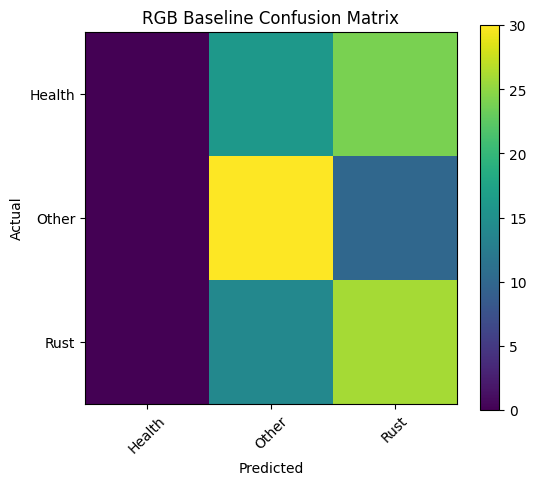

In [27]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(yva, yp)

print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("RGB Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(cls)), cls, rotation=45)
plt.yticks(range(len(cls)), cls)
plt.colorbar()
plt.show()

In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

nc = len(cls)

m2 = Sequential()

m2.add(Input(shape=(64, 64, 5)))

m2.add(Conv2D(32, (3, 3), activation="relu", padding="same"))
m2.add(MaxPooling2D((2, 2)))

m2.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
m2.add(MaxPooling2D((2, 2)))

m2.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
m2.add(MaxPooling2D((2, 2)))

m2.add(BatchNormalization())

m2.add(GlobalAveragePooling2D())

m2.add(Dense(128, activation="relu"))

m2.add(Dropout(0.3))

m2.add(Dense(nc, activation="softmax"))

m2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 64, 64, 32)          │           1,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 111,235 (434.51 KB)

 Trainable params: 110,979 (433.51 KB)

 Non-trainable params: 256 (1.00 KB)

In [29]:
m2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("MS baseline model compiled successfully")

MS baseline model compiled successfully


In [30]:
es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

h2 = m2.fit(
    xtr_ms, ytr_ms,
    validation_data=(xva_ms, yva_ms),
    epochs=15,
    batch_size=32,
    callbacks=[es]
)

Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.5417 - loss: 0.8961 - val_accuracy: 0.4500 - val_loss: 1.0543
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.5750 - loss: 0.8511 - val_accuracy: 0.4083 - val_loss: 1.0588
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.6125 - loss: 0.8040 - val_accuracy: 0.3417 - val_loss: 1.0592
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.6000 - loss: 0.8095 - val_accuracy: 0.6000 - val_loss: 1.0269
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.6438 - loss: 0.7829 - val_accuracy: 0.5833 - val_loss: 1.0267
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.6417 - loss: 0.7710 - val_accuracy: 0.5833 - val_loss: 1.0073
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.6417 - loss: 0.7598 - val_accuracy: 0.6167 - val_loss: 1.0039
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.6562 - loss: 0.7520 - val_accuracy: 0.4833 - v

In [31]:
# تقييم مودل MS
loss2, acc2 = m2.evaluate(xva_ms, yva_ms)

print("MS Baseline Loss:", loss2)
print("MS Baseline Accuracy:", acc2)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6417 - loss: 0.9294
MS Baseline Loss: 0.9293750524520874
MS Baseline Accuracy: 0.6416666507720947


In [32]:
from sklearn.metrics import classification_report
import numpy as np

pr2 = m2.predict(xva_ms)

yp2 = np.argmax(pr2, axis=1)

print(classification_report(yva_ms, yp2, target_names=cls, zero_division=0))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
              precision    recall  f1-score   support

      Health       0.88      0.17      0.29        40
       Other       0.94      0.75      0.83        40
        Rust       0.50      1.00      0.67        40

    accuracy                           0.64       120
   macro avg       0.77      0.64      0.60       120
weighted avg       0.77      0.64      0.60       120



[[ 7  2 31]
 [ 1 30  9]
 [ 0  0 40]]


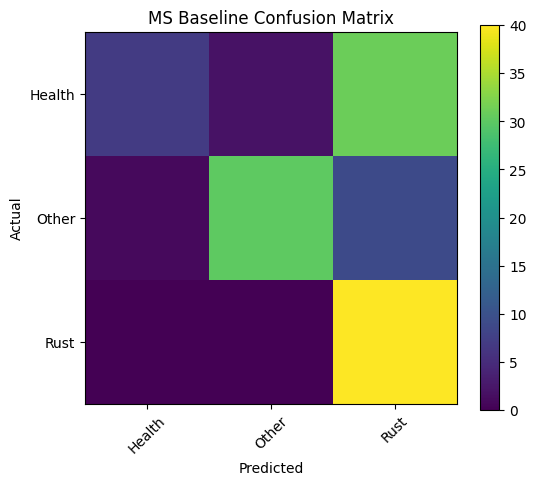

In [33]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm2 = confusion_matrix(yva_ms, yp2)

print(cm2)

plt.figure(figsize=(6, 5))
plt.imshow(cm2)
plt.title("MS Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(cls)), cls, rotation=45)
plt.yticks(range(len(cls)), cls)
plt.colorbar()
plt.show()

In [34]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.models import Model

nc = len(cls)



ms_in = Input(shape=(64, 64, 5))  

x1 = Conv2D(32, (3, 3), activation="relu", padding="same")(ms_in)
x1 = MaxPooling2D((2, 2))(x1)

x1 = Conv2D(64, (3, 3), activation="relu", padding="same")(x1)
x1 = MaxPooling2D((2, 2))(x1)

x1 = Conv2D(128, (3, 3), activation="relu", padding="same")(x1)
x1 = MaxPooling2D((2, 2))(x1)

x1 = BatchNormalization()(x1)
x1 = GlobalAveragePooling2D()(x1)




hs_in = Input(shape=(32, 32, 125))  # مدخل صور HS

x2 = Conv2D(32, (3, 3), activation="relu", padding="same")(hs_in)
x2 = MaxPooling2D((2, 2))(x2)

x2 = Conv2D(64, (3, 3), activation="relu", padding="same")(x2)
x2 = MaxPooling2D((2, 2))(x2)

x2 = Conv2D(128, (3, 3), activation="relu", padding="same")(x2)
x2 = MaxPooling2D((2, 2))(x2)

x2 = BatchNormalization()(x2)
x2 = GlobalAveragePooling2D()(x2)




x = Concatenate()([x1, x2])  # دمج features من MS و HS

x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

out = Dense(nc, activation="softmax")(x)  # output layer

mf = Model(inputs=[ms_in, hs_in], outputs=out)

mf.summary()

Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 64, 64, 5)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_3 (InputLayer)    │ (None, 32, 32, 125)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 64, 64, 32)        │           1,472 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_9 (Conv2D)             │ (None, 32, 32, 32)        │          36,032 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_6               │ (None, 32, 32, 32)        │               0 │ conv2d_6[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_9               │ (None, 16, 16, 32)        │               0 │ conv2d_9[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_7 (Conv2D)             │ (None, 32, 32, 64)        │          18,496 │ max_pooling2d_6[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_10 (Conv2D)            │ (None, 16, 16, 64)        │          18,496 │ max_pooling2d_9[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_7               │ (None, 16, 16, 64)        │               0 │ conv2d_7[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_10              │ (None, 8, 8, 64)          │               0 │ conv2d_10[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_8 (Conv2D)             │ (None, 16, 16, 128)       │          73,856 │ max_pooling2d_7[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_11 (Conv2D)            │ (None, 8, 8, 128)         │          73,856 │ max_pooling2d_10[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_8               │ (None, 8, 8, 128)         │               0 │ conv2d_8[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_11              │ (None, 4, 4, 128)         │               0 │ conv2d_11[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 256,515 (1002.01 KB)

 Trainable params: 256,003 (1000.01 KB)

 Non-trainable params: 512 (2.00 KB)

In [35]:
mf.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fusion model compiled successfully")

Fusion model compiled successfully


In [36]:
es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

hf = mf.fit(
    [xtr_ms, xtr_hs], ytr_ms,
    validation_data=([xva_ms, xva_hs], yva_ms),
    epochs=15,
    batch_size=32,
    callbacks=[es]
)

Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - accuracy: 0.5375 - loss: 0.9210 - val_accuracy: 0.3083 - val_loss: 1.9870
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - accuracy: 0.5542 - loss: 0.8922 - val_accuracy: 0.3083 - val_loss: 2.0161
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - accuracy: 0.5729 - loss: 0.8446 - val_accuracy: 0.3083 - val_loss: 1.9504
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - accuracy: 0.5500 - loss: 0.8556 - val_accuracy: 0.3167 - val_loss: 1.4938
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.5813 - loss: 0.8532 - val_accuracy: 0.4417 - val_loss: 1.2037
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.5979 - loss: 0.8180 - val_accuracy: 0.5167 - val_loss: 1.0975
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - accuracy: 0.6417 - loss: 0.7709 - val_accuracy: 0.5083 - val_loss: 1.0187
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.6438 - loss: 0.7657 - val_accuracy: 0.

In [37]:
lossf, accf = mf.evaluate([xva_ms, xva_hs], yva_ms)

print("Fusion Model Loss:", lossf)
print("Fusion Model Accuracy:", accf)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4667 - loss: 0.9697
Fusion Model Loss: 0.9696688055992126
Fusion Model Accuracy: 0.46666666865348816


In [38]:
from sklearn.metrics import classification_report
import numpy as np

prf = mf.predict([xva_ms, xva_hs])

ypf = np.argmax(prf, axis=1)

print(classification_report(yva_ms, ypf, target_names=cls, zero_division=0))

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step WARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001D43F6FB560> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
              precision    recall  f1-score   support

      Health       0.25      0.07      0.12        40
       Other       0.54      0.78      0.64        40
        Rust       0.43      0.55 

[[ 3 11 26]
 [ 6 31  3]
 [ 3 15 22]]


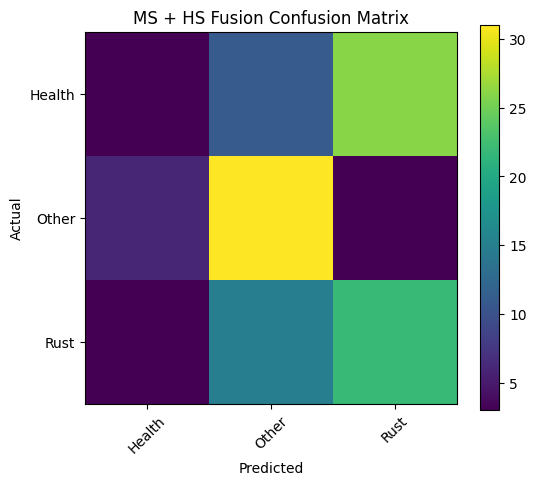

In [39]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cmf = confusion_matrix(yva_ms, ypf)

print(cmf)

plt.figure(figsize=(6, 5))
plt.imshow(cmf)
plt.title("MS + HS Fusion Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(cls)), cls, rotation=45)
plt.yticks(range(len(cls)), cls)
plt.colorbar()
plt.show()

In [40]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

pr_rgb = m1.predict(xva_rgb)

pr_ms = m2.predict(xva_ms)

best_acc = 0
best_w = 0

for w in np.arange(0, 1.1, 0.1):
    
    
    pr_f = (w * pr_rgb) + ((1 - w) * pr_ms)

    yp_f = np.argmax(pr_f, axis=1)

    acc = accuracy_score(yva, yp_f)

    print("RGB weight:", round(w, 1), "| MS weight:", round(1-w, 1), "| Accuracy:", acc)

    if acc > best_acc:
        best_acc = acc
        best_w = w

print("\nBest RGB weight:", best_w)
print("Best MS weight:", 1 - best_w)
print("Best Fusion Accuracy:", best_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 292ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
RGB weight: 0.0 | MS weight: 1.0 | Accuracy: 0.6416666666666667
RGB weight: 0.1 | MS weight: 0.9 | Accuracy: 0.6416666666666667
RGB weight: 0.2 | MS weight: 0.8 | Accuracy: 0.6333333333333333
RGB weight: 0.3 | MS weight: 0.7 | Accuracy: 0.6166666666666667
RGB weight: 0.4 | MS weight: 0.6 | Accuracy: 0.6166666666666667
RGB weight: 0.5 | MS weight: 0.5 | Accuracy: 0.6166666666666667
RGB weight: 0.6 | MS weight: 0.4 | Accuracy: 0.6083333333333333
RGB weight: 0.7 | MS weight: 0.3 | Accuracy: 0.6
RGB weight: 0.8 | MS weight: 0.2 | Accuracy: 0.5833333333333334
RGB weight: 0.9 | MS weight: 0.1 | Accuracy: 0.55
RGB weight: 1.0 | MS weight: 0.0 | Accuracy: 0.4666666666666667

Best RGB weight: 0.0
Best MS weight: 1.0
Best Fusion Accuracy: 0.6416666666666667


In [41]:
pr_final = (best_w * pr_rgb) + ((1 - best_w) * pr_ms)

yp_final = np.argmax(pr_final, axis=1)

print(classification_report(yva, yp_final, target_names=cls, zero_division=0))

              precision    recall  f1-score   support

      Health       0.88      0.17      0.29        40
       Other       0.94      0.75      0.83        40
        Rust       0.50      1.00      0.67        40

    accuracy                           0.64       120
   macro avg       0.77      0.64      0.60       120
weighted avg       0.77      0.64      0.60       120



[[ 7  2 31]
 [ 1 30  9]
 [ 0  0 40]]


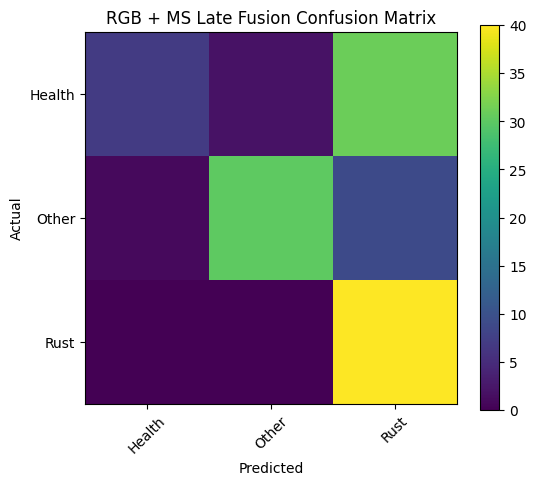

In [42]:
cm_final = confusion_matrix(yva, yp_final)

print(cm_final)

plt.figure(figsize=(6, 5))
plt.imshow(cm_final)
plt.title("RGB + MS Late Fusion Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(cls)), cls, rotation=45)
plt.yticks(range(len(cls)), cls)
plt.colorbar()
plt.show()

In [43]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

nc = len(cls)

m3 = Sequential()

m3.add(Input(shape=(64, 64, 5)))

m3.add(Conv2D(32, (3, 3), activation="relu", padding="same", kernel_regularizer=l2(0.001)))
m3.add(BatchNormalization())
m3.add(MaxPooling2D((2, 2)))

m3.add(Conv2D(64, (3, 3), activation="relu", padding="same", kernel_regularizer=l2(0.001)))
m3.add(BatchNormalization())
m3.add(MaxPooling2D((2, 2)))

m3.add(Conv2D(128, (3, 3), activation="relu", padding="same", kernel_regularizer=l2(0.001)))
m3.add(BatchNormalization())
m3.add(MaxPooling2D((2, 2)))

m3.add(Conv2D(256, (3, 3), activation="relu", padding="same", kernel_regularizer=l2(0.001)))
m3.add(BatchNormalization())
m3.add(MaxPooling2D((2, 2)))

m3.add(GlobalAveragePooling2D())

m3.add(Dense(128, activation="relu", kernel_regularizer=l2(0.001)))

m3.add(Dropout(0.4))

m3.add(Dense(nc, activation="softmax"))

m3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 64, 64, 32)          │           1,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64, 64, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 8, 8, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_4           │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 424,195 (1.62 MB)

 Trainable params: 423,235 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [44]:
opt = Adam(learning_rate=0.0005)

m3.compile(
    optimizer=opt,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Improved MS model compiled successfully")

Improved MS model compiled successfully


In [45]:
es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=0.00001
)

h3 = m3.fit(
    xtr_ms, ytr_ms,
    validation_data=(xva_ms, yva_ms),
    epochs=25,
    batch_size=32,
    callbacks=[es, lr]
)

Epoch 1/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 241ms/step - accuracy: 0.5104 - loss: 1.7234 - val_accuracy: 0.3750 - val_loss: 1.5552 - learning_rate: 5.0000e-04
Epoch 2/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 224ms/step - accuracy: 0.5875 - loss: 1.4363 - val_accuracy: 0.3167 - val_loss: 1.5736 - learning_rate: 5.0000e-04
Epoch 3/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 216ms/step - accuracy: 0.6271 - loss: 1.3319 - val_accuracy: 0.3250 - val_loss: 1.5965 - learning_rate: 5.0000e-04
Epoch 4/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 232ms/step - accuracy: 0.6562 - loss: 1.2362 - val_accuracy: 0.3333 - val_loss: 1.6246 - learning_rate: 2.5000e-04
Epoch 5/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 216ms/step - accuracy: 0.6646 - loss: 1.2158 - val_accuracy: 0.3333 - val_loss: 1.6789 - learning_rate: 2.5000e-04


In [46]:
# تقييم المودل
loss3, acc3 = m3.evaluate(xva_ms, yva_ms)

print("Improved MS Loss:", loss3)
print("Improved MS Accuracy:", acc3)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3750 - loss: 1.5552
Improved MS Loss: 1.5551807880401611
Improved MS Accuracy: 0.375


In [47]:
from sklearn.metrics import classification_report
import numpy as np

pr3 = m3.predict(xva_ms)

yp3 = np.argmax(pr3, axis=1)

print(classification_report(yva_ms, yp3, target_names=cls, zero_division=0))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
              precision    recall  f1-score   support

      Health       0.00      0.00      0.00        40
       Other       0.83      0.12      0.22        40
        Rust       0.35      1.00      0.52        40

    accuracy                           0.38       120
   macro avg       0.39      0.38      0.25       120
weighted avg       0.39      0.38      0.25       120



[[ 0  1 39]
 [ 0  5 35]
 [ 0  0 40]]


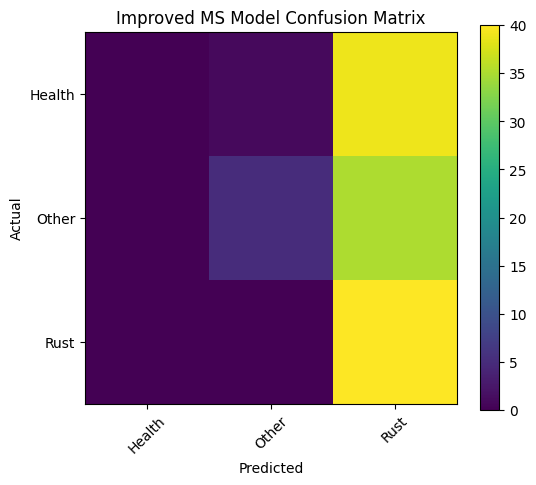

In [48]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm3 = confusion_matrix(yva_ms, yp3)

print(cm3)

plt.figure(figsize=(6, 5))
plt.imshow(cm3)
plt.title("Improved MS Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(cls)), cls, rotation=45)
plt.yticks(range(len(cls)), cls)
plt.colorbar()
plt.show()

In [49]:
print("Model Comparison")
print("-------------------------")
print("RGB Baseline Accuracy:", acc)
print("MS Baseline Accuracy:", acc2)
print("MS + HS Fusion Accuracy:", accf)
print("RGB + MS Late Fusion Accuracy:", best_acc)
print("Improved MS Accuracy:", acc3)

Model Comparison
-------------------------
RGB Baseline Accuracy: 0.4666666666666667
MS Baseline Accuracy: 0.6416666507720947
MS + HS Fusion Accuracy: 0.46666666865348816
RGB + MS Late Fusion Accuracy: 0.6416666666666667
Improved MS Accuracy: 0.375


In [50]:


val_ms = "Kaggle_Prepared/val/MS"


cls = ["Health", "Other", "Rust"]

def load_one_ms(p):
    img = tiff.imread(p)
    arr = np.array(img, dtype="float32")
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    return arr

ids = []
xs = []

for f in sorted(os.listdir(val_ms)):
    if f.lower().endswith(".tif"):
        p = os.path.join(val_ms, f)

        ids.append(f)  # مهم: نخلي الاسم مع .tif
        xs.append(load_one_ms(p))

x_submit = np.array(xs, dtype="float32")

print("Submission data shape:", x_submit.shape)
print("Number of samples:", len(ids))

pred = m2.predict(x_submit)

pred_cls = np.argmax(pred, axis=1)
pred_labels = [cls[i] for i in pred_cls]

sub = pd.DataFrame({
    "Id": ids,
    "Category": pred_labels
})

sub.to_csv("submission.csv", index=False)

print(sub.head())
print(sub.columns)
print("submission.csv fixed successfully")

Submission data shape: (300, 64, 64, 5)
Number of samples: 300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
                 Id Category
0  val_000a83c1.tif     Rust
1  val_00a704b1.tif    Other
2  val_01dde030.tif    Other
3  val_024df365.tif     Rust
4  val_02afcb0e.tif     Rust
Index(['Id', 'Category'], dtype='object')
submission.csv fixed successfully
